# Homework Week 1 - Linear Algebra for AI

This notebook uses a text dataset with 8 English sentences.

The goal is to represent text as a matrix, compute cosine similarity, implement search, and use SVD to reduce sentence vectors to 2D.

In [46]:
import numpy as np
import matplotlib.pyplot as plt

In [47]:
sentences = [
    "astronauts explore the deep space",
    "telescopes observe stars in space",
    "planets orbit around bright stars",
    "astronauts travel to new planets",
    "musicians play guitar on stage",
    "singers perform songs on stage",
    "fans listen to pop music",
    "musicians write new pop songs"
]

for i, s in enumerate(sentences, start=1):
    print(f"s{i}: {s}")

s1: astronauts explore the deep space
s2: telescopes observe stars in space
s3: planets orbit around bright stars
s4: astronauts travel to new planets
s5: musicians play guitar on stage
s6: singers perform songs on stage
s7: fans listen to pop music
s8: musicians write new pop songs


## Dataset

The dataset contains 8 English sentences from two topics:

- Space: s1 to s4
- Music: s5 to s8

The sentences are short and include repeated topic-related words, so cosine similarity and SVD can show relationships between them.

## 1. Text representation as a matrix

Each sentence is converted into a bag-of-words vector.  
Each row of the matrix represents one sentence.  
Each column represents one word in the vocabulary.

In [48]:
vocab = sorted({word for sentence in sentences for word in sentence.lower().split()})

print("Vocabulary size:", len(vocab))
print(vocab)

Vocabulary size: 29
['around', 'astronauts', 'bright', 'deep', 'explore', 'fans', 'guitar', 'in', 'listen', 'music', 'musicians', 'new', 'observe', 'on', 'orbit', 'perform', 'planets', 'play', 'pop', 'singers', 'songs', 'space', 'stage', 'stars', 'telescopes', 'the', 'to', 'travel', 'write']


In [49]:
def to_vector(sentence):
    vector = np.zeros(len(vocab))

    for word in sentence.lower().split():
        if word in vocab:
            index = vocab.index(word)
            vector[index] += 1

    return vector


X = np.array([to_vector(sentence) for sentence in sentences])

print("X shape:", X.shape)
print(X)

X shape: (8, 29)
[[0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1.
  1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0.
  0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 1.]]


## 2. Column mean and broadcasting

We compute the mean vector along columns.  
Then we subtract this mean vector from every row of X using NumPy broadcasting.

This centers the data, so each column has mean close to zero after centering.

In [50]:
mean_vector = X.mean(axis=0)
X_centered = X - mean_vector

print("X shape:", X.shape)
print("Mean vector shape:", mean_vector.shape)
print("X centered shape:", X_centered.shape)

print("First 5 values of mean vector:")
print(mean_vector[:5])

print("Column sums after centering:")
print(X_centered.sum(axis=0))

X shape: (8, 29)
Mean vector shape: (29,)
X centered shape: (8, 29)
First 5 values of mean vector:
[0.125 0.25  0.125 0.125 0.125]
Column sums after centering:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


## 3. Cosine similarity

Cosine similarity measures how similar two vectors are by comparing their directions.

For a batch of vectors, each row of X is normalized to length 1.  
Then the similarity matrix is computed by multiplying the normalized matrix with its transpose.

In [51]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X

    X_norm = np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)

    Xn = X / X_norm
    Yn = Y / Y_norm

    return Xn @ Yn.T


S = cosine_similarity(X)

print("Similarity matrix shape:", S.shape)
print(np.round(S, 3))

Similarity matrix shape: (8, 8)
[[1.  0.2 0.  0.2 0.  0.  0.  0. ]
 [0.2 1.  0.2 0.  0.  0.  0.  0. ]
 [0.  0.2 1.  0.2 0.  0.  0.  0. ]
 [0.2 0.  0.2 1.  0.  0.  0.2 0.2]
 [0.  0.  0.  0.  1.  0.4 0.  0.2]
 [0.  0.  0.  0.  0.4 1.  0.  0.2]
 [0.  0.  0.  0.2 0.  0.  1.  0.2]
 [0.  0.  0.  0.2 0.2 0.2 0.2 1. ]]


In [52]:
print("cosine(s1, s2):", round(S[0, 1], 3))
print("cosine(s5, s6):", round(S[4, 5], 3))
print("cosine(s7, s8):", round(S[6, 7], 3))
print("cosine(s3, s8):", round(S[2, 7], 3))

cosine(s1, s2): 0.2
cosine(s5, s6): 0.4
cosine(s7, s8): 0.2
cosine(s3, s8): 0.0


## 4. Search with cosine similarity

The search function converts a query sentence into a bag-of-words vector using the same vocabulary.  
Then it computes cosine similarity between the query and all sentences in X.  
The sentences with the highest cosine scores are returned as the most similar results.

In [53]:
def search(query, top_k=3):
    query_vector = to_vector(query)
    query_vector = query_vector.reshape(1, -1)

    scores = cosine_similarity(query_vector, X)
    scores = scores[0]

    sorted_indices = np.argsort(scores)[::-1]
    top_indices = sorted_indices[:top_k]

    results = []

    for i in top_indices:
        results.append((i, sentences[i], scores[i]))

    return results


query = "astronauts observe space"
results = search(query, top_k=3)

print("Query:", query)

for index, sentence, score in results:
    print(f"s{index + 1}: {sentence} | score = {score:.3f}")

Query: astronauts observe space
s2: telescopes observe stars in space | score = 0.516
s1: astronauts explore the deep space | score = 0.516
s4: astronauts travel to new planets | score = 0.258


The query "astronauts observe space" is closest to s1 and s2.  
s1 shares the words "astronauts" and "space" with the query.  
s2 shares the words "observe" and "space" with the query.  
s4 has a lower score because it only shares the word "astronauts".

This result matches intuition because the query is related to the Space topic.

## 5. Similarity analysis

We analyze the cosine similarity matrix to find the most similar and most different sentence pairs.

In [54]:
S_no_diag = S.copy()
np.fill_diagonal(S_no_diag, -np.inf)

most_similar = np.unravel_index(np.argmax(S_no_diag), S_no_diag.shape)

S_no_diag_min = S.copy()
np.fill_diagonal(S_no_diag_min, np.inf)

most_different = np.unravel_index(np.argmin(S_no_diag_min), S_no_diag_min.shape)

i, j = most_similar
print("Most similar pair:")
print(f"s{i+1}: {sentences[i]}")
print(f"s{j+1}: {sentences[j]}")
print("Score:", round(S[i, j], 3))

i, j = most_different
print("\nMost different pair:")
print(f"s{i+1}: {sentences[i]}")
print(f"s{j+1}: {sentences[j]}")
print("Score:", round(S[i, j], 3))

Most similar pair:
s5: musicians play guitar on stage
s6: singers perform songs on stage
Score: 0.4

Most different pair:
s1: astronauts explore the deep space
s3: planets orbit around bright stars
Score: 0.0


### Observation

The most similar pair has the highest cosine similarity because the two sentences share more words.

For example, s5 and s6 share the words "on" and "stage", so their cosine similarity is high compared with pairs that share only one word.

The most different pairs usually have no shared words, so their cosine similarity is 0.

Overall, the result matches intuition because sentences from the same topic tend to share more vocabulary. However, some common words such as "on", "to", "the", and "in" may affect the scores. Removing stop words could make the similarity more meaningful.

# 2. Linear transformation and SVD

For the text option, we use the matrix X from Part 1.

The goal is to reduce each sentence vector from 29 dimensions to 2 dimensions using SVD.  
Then we visualize the 8 sentences on a 2D scatter plot.

In [55]:
Xc = X - X.mean(axis=0)

U, singular_values, Vt = np.linalg.svd(Xc, full_matrices=False)

coords = U[:, :2] * singular_values[:2]

print("X shape:", X.shape)
print("X centered shape:", Xc.shape)
print("U shape:", U.shape)
print("Singular values shape:", singular_values.shape)
print("Vt shape:", Vt.shape)
print("Coords shape:", coords.shape)

X shape: (8, 29)
X centered shape: (8, 29)
U shape: (8, 8)
Singular values shape: (8,)
Vt shape: (8, 29)
Coords shape: (8, 2)


The matrix X has shape (8, 29), so each sentence is represented by a 29-dimensional vector.

After SVD, coords has shape (8, 2).  
Each row of coords is the 2D position of one sentence.

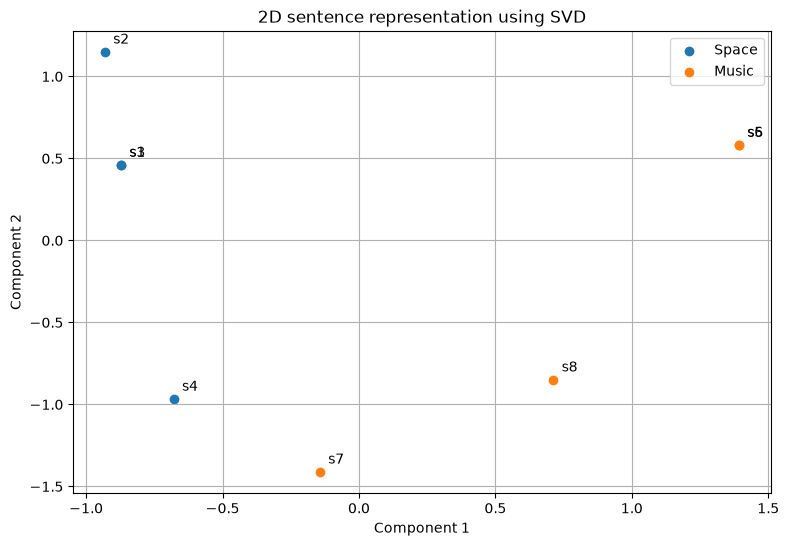

In [56]:
labels = [f"s{i+1}" for i in range(len(sentences))]
colors = ["Space"] * 4 + ["Music"] * 4

plt.figure(figsize=(9, 6))

for topic in ["Space", "Music"]:
    indices = [i for i, c in enumerate(colors) if c == topic]
    plt.scatter(coords[indices, 0], coords[indices, 1], label=topic)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (coords[i, 0], coords[i, 1]),
        textcoords="offset points",
        xytext=(6, 6)
    )

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("2D sentence representation using SVD")
plt.grid(True)
plt.legend()
plt.show()

### SVD observation

The scatter plot shows the 2D representation of the 8 sentences after SVD.

Sentences from the same topic may appear closer because they share related vocabulary.  
Space sentences are s1 to s4, while music sentences are s5 to s8.

The separation is not perfect because the bag-of-words representation is simple and only counts word overlap. Common words can also affect the position of each sentence.